# **UCI-HAR -Transformer (PyTorch)**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch 관련 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data load

In [3]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [4]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
# 1. X 데이터 로드 함수 수정 (파이토치 1D CNN 차원에 맞춤)
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # [기존] 텐서플로우용: (1, 2, 0) -> (샘플 수, 타임스텝 수, 특성 수)
    # [수정] 파이토치용:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    # 파이토치 nn.Conv1d는 채널(특성 수)이 중간에 와야 한다.
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [6]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("\n=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])


=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model Building

Psitional Encoding (위치 정보 입력)

In [7]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return x

Transformer block
- in_channels: 입력 데이터의 채널 수 (기본값: 9)
- num_classes: 최종 분류할 클래스 수 (기본값: 6)
- d_model: Transformer 내부의 특징(Embedding) 차원 (기본값: 128)
- nhead: Multi-head Attention의 헤드 수 (d_model의 약수여야 함)
- num_layers: Transformer Encoder 블록의 개수
- dim_feedforward: Feed-Forward 네트워크의 은닉층 차원 (기본값: 256)
- dropout: 과적합 방지를 위한 드롭아웃 확률

In [8]:
class TransformerNet1D(nn.Module):
    def __init__(self, in_channels=9, num_classes=6, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.3):

        super(TransformerNet1D, self).__init__()

        # 입력 채널(9)을 Transformer 임베딩 차원(128)으로 변환
        self.input_projection = nn.Linear(in_channels, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=128)

        # Transformer Encoder Stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # (Batch, Seq, Feature) 구조 사용
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 시간축(Sequence)에 대한 평균 풀링
        # Transformer를 거치면 (Batch, Seq, d_model)이므로 d_model 차원만 남기기 위함

        # Transformer의 출력 차원(d_model=128)을 Classifier 입력(256)으로 매핑 후 레이어 진행
        self.fc = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # 1. 기존 DepthwiseNet1D 입력 규격 처리: (Batch, Channel, Seq) -> (32, 9, 128)
        # Transformer 연산을 위해 축을 전환: (Batch, Seq, Channel) -> (32, 128, 9)
        x = x.permute(0, 2, 1)

        # 2. Input Embedding & 위치 인코딩 적용
        x = self.input_projection(x)  # (Batch, 128, 128)
        x = self.pos_encoder(x)       # (Batch, 128, 128)

        # 3. Transformer Encoder 블록 통과 (시간적 컨텍스트 및 복합 특징 추출)
        x = self.transformer_encoder(x)  # (Batch, 128, 128)

        # 4. Global Average Pooling (Sequence 축을 평균 내어 압축)
        # 128개의 타임스텝에 대한 평균 -> (Batch, d_model) -> (32, 128)
        x = x.mean(dim=1)

        # 5. Dense Layer Classifier 통과
        output = self.fc(x)  # (Batch, num_classes) -> (32, 6)
        return output

Model building

In [15]:
if __name__ == "__main__":
    # GPU 사용 가능 여부 확인
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 모델 생성
    model = TransformerNet1D(in_channels=9, num_classes=6).to(device)
    print(model)

    # (Batch=16, Channel=9, Seq_len=128)
    dummy_x = torch.randn(16, 9, 128).to(device)

    # 예측 수행
    dummy_out = model(dummy_x)
    print(f"\n입력 데이터 형태: {dummy_x.shape}")
    print(f"출력 데이터 형태: {dummy_out.shape}")  # torch.Size([16, 6])

TransformerNet1D(
  (input_projection): Linear(in_features=9, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

Loss + Callbacks

In [16]:
import copy
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 손실함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau 스케줄러 정의
lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=8,
    min_lr=0.00001
)

# ModelCheckpoint 및 EarlyStopping 정의
early_stopping_patience = 25
patience_counter = 0

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

checkpoint_path = "UCI_HAR_Transformer_best.pt"


# Model train

In [17]:
import time
from torch.utils.data import TensorDataset, random_split

# --- 1. Dataset 및 DataLoader 준비 ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)  # 원-핫 인코딩 대신 정수형 레이블 사용

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [18]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [19]:
# --- 3. 학습 및 검증 루프 실행 (epochs=100) ---
epochs = 100

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # [Train Phase]
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 검증 시에는 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에포크 결과 출력
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --- 4. Callbacks 수동 연동 단계 ---
    # (1) ReduceLROnPlateau 스케줄러 업데이트
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping triggered. Restoring model weights from the end of the best epoch.")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

Epoch 1/100 - 3.6s - loss: 0.4984 - accuracy: 0.8090 - val_loss: 0.5349 - val_accuracy: 0.7668 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.76683, saving model to UCI_HAR_Transformer_best.pt
Epoch 2/100 - 3.4s - loss: 0.2860 - accuracy: 0.8912 - val_loss: 0.3683 - val_accuracy: 0.8518 - lr: 0.001000
Epoch 2: val_categorical_accuracy improved to 0.85180, saving model to UCI_HAR_Transformer_best.pt
Epoch 3/100 - 3.9s - loss: 0.2407 - accuracy: 0.9131 - val_loss: 0.1828 - val_accuracy: 0.9150 - lr: 0.001000
Epoch 3: val_categorical_accuracy improved to 0.91502, saving model to UCI_HAR_Transformer_best.pt
Epoch 4/100 - 4.6s - loss: 0.2116 - accuracy: 0.9203 - val_loss: 0.2112 - val_accuracy: 0.9171 - lr: 0.001000
Epoch 4: val_categorical_accuracy improved to 0.91706, saving model to UCI_HAR_Transformer_best.pt
Epoch 5/100 - 4.5s - loss: 0.2098 - accuracy: 0.9189 - val_loss: 0.3345 - val_accuracy: 0.8885 - lr: 0.001000
Epoch 6/100 - 4.6s - loss: 0.2141 - accuracy: 0.9121 -

# Evaluation

best 기록 확인

In [20]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
best_model = TransformerNet1D(in_channels=9, num_classes=6).to(device)

# 가중치 파일(.pt) 로드
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 ---
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):

    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
# X_train 전체 데이터에 대해 평가
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

# X_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Successfully loaded best model weights from UCI_HAR_Transformer_best.pt
Training accuracy: 95.70%
Training loss: 0.1055
Test accuracy: 88.06%
Test loss: 0.6893


Classification Report

In [21]:
import torch.nn.functional as F

# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device) # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(batch_X)

        # 로짓을 소프트맥스를 통해 확률값(0~1 사이)으로 변환
        probabilities = F.softmax(outputs, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\nClassification Report:")
# y_test는 이미 정수형 레이블(0~5)이므로 그대로 사용
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9060    0.8548    0.8797       496
           1     0.9161    0.8577    0.8860       471
           2     0.8458    0.9405    0.8906       420
           3     0.8024    0.8106    0.8065       491
           4     0.8245    0.8214    0.8230       532
           5     0.9853    1.0000    0.9926       537

    accuracy                         0.8806      2947
   macro avg     0.8800    0.8808    0.8797      2947
weighted avg     0.8815    0.8806    0.8804      2947



Loss / Accuracy 그래프

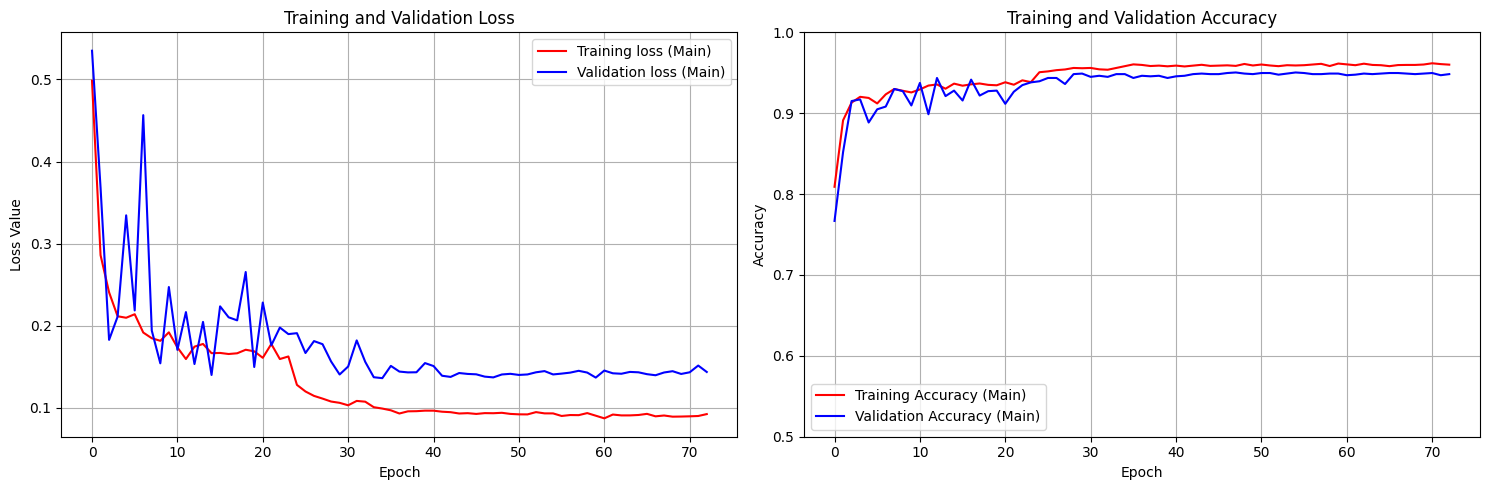

In [22]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

혼동 행렬 (Confusion Matrix)

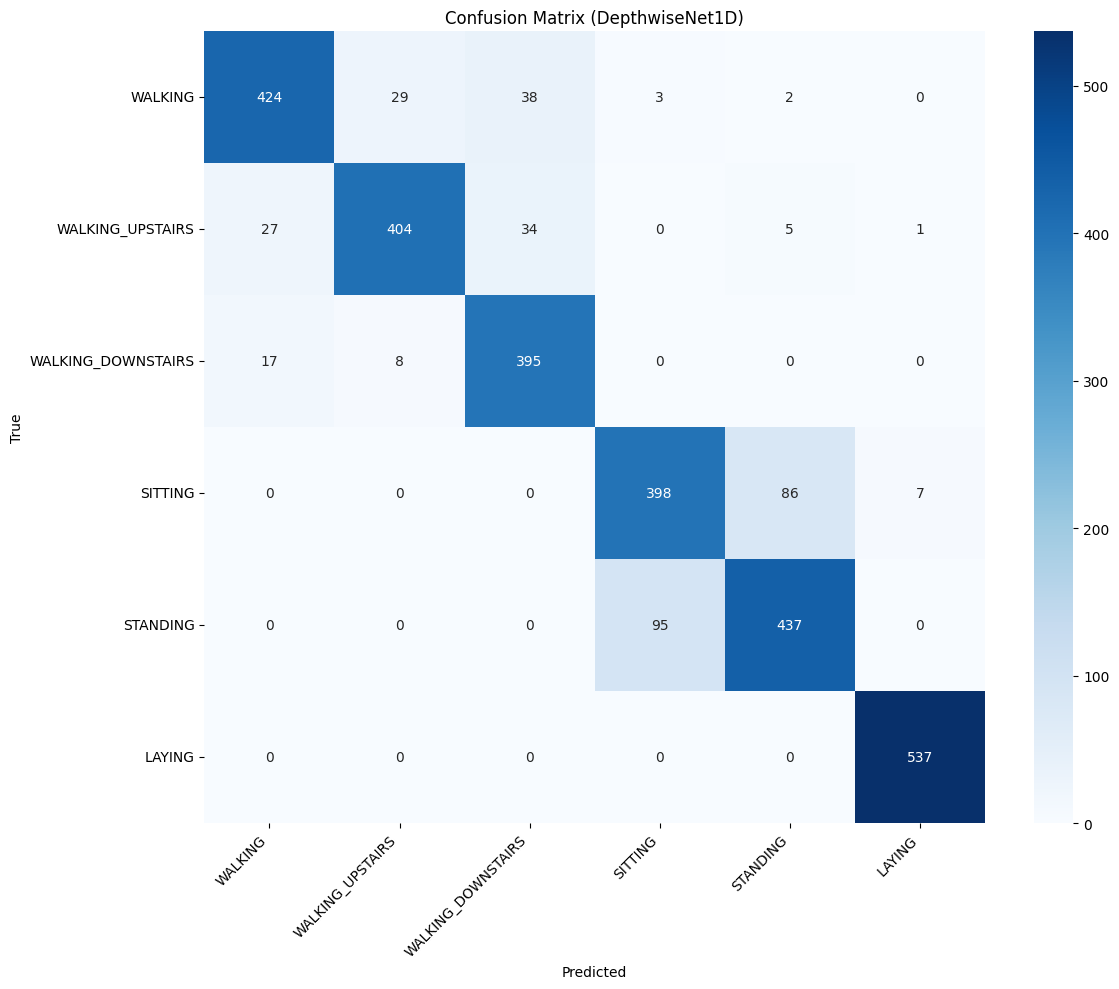

In [23]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (DepthwiseNet1D)')

# 클래스 개수에 맞게 축 레이블(WALKING, SITTING 등) 설정
n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()